In [1]:
import numpy as np

# 기본 구현
np.random.seed(0)  # 시드 고정
rewards = []

for n in range(1, 11):  # 10번 플레이
    reward = np.random.rand()  # 보상(무작위수로 시뮬레이션)
    rewards.append(reward)
    Q = sum(rewards) / n
    print(f'{n}번 플레이, 행동 가치 {Q}')

1번 플레이, 행동 가치 0.5488135039273248
2번 플레이, 행동 가치 0.6320014351498722
3번 플레이, 행동 가치 0.6222554154571294
4번 플레이, 행동 가치 0.6029123573420713
5번 플레이, 행동 가치 0.567060845741438
6번 플레이, 행동 가치 0.5801997236289743
7번 플레이, 행동 가치 0.5598265075766483
8번 플레이, 행동 가치 0.6013198192273272
9번 플레이, 행동 가치 0.6415801460355164
10번 플레이, 행동 가치 0.6157662833145425


In [2]:
# 증분 구현
np.random.seed(0)
Q = 0

for n in range(1, 11):
    reward = np.random.rand()
    Q = Q + (reward - Q) / n  # [식 1.5]
    print(f'{n}번 플레이, 행동 가치 {Q}')


1번 플레이, 행동 가치 0.5488135039273248
2번 플레이, 행동 가치 0.6320014351498722
3번 플레이, 행동 가치 0.6222554154571294
4번 플레이, 행동 가치 0.6029123573420713
5번 플레이, 행동 가치 0.567060845741438
6번 플레이, 행동 가치 0.5801997236289743
7번 플레이, 행동 가치 0.5598265075766483
8번 플레이, 행동 가치 0.6013198192273272
9번 플레이, 행동 가치 0.6415801460355164
10번 플레이, 행동 가치 0.6157662833145425


In [15]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트 설정(윈도우 기본 폰트)
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 기호 깨짐 방지

class Bandit:
    def __init__(self, arms=10):  # arms = 슬롯머신 대수
        self.rates = np.random.rand(arms)  # 슬롯머신 각각의 승률 설정(무작위)

    def play(self, arm):
        rate = self.rates[arm]
        # 무작위 수가 승률보다 크면 보상으로 코인 1개를 반환
        if rate > np.random.rand():
            return 1
        else:
            return 0



In [5]:
bandit = Bandit()

for i in range(3):
    print(bandit.play(0))

0
0
1


In [ ]:
bandit = Bandit()

Q = 0

for n in range(1, 11): # 10번 반복
    reward = bandit.play(0) # 0번째 슬롯머신 플레이
    Q += (reward - Q) / n # 가치 추정치 갱신
    print(Q)

1.0
1.0
1.0
1.0
1.0
0.8333333333333334
0.8571428571428572
0.875
0.8888888888888888
0.8999999999999999


In [3]:
bandit = Bandit()
NUM_SLOTS = 5 # 슬롯머신의 개수

Qs = np.zeros(NUM_SLOTS) # 각 슬롯머신의 가치 추정치
ns = np.zeros(NUM_SLOTS) # 각 슬롯머신의 플레이 횟수

for n in range(10):
    action = np.random.randint(0, NUM_SLOTS) # 임의의 슬롯머신 선택
    reward = bandit.play(action)

    ns[action] += 1 # action번째 슬롯머신을 플레이한 횟수를 증가시킴
    Qs[action] += (reward - Qs[action]) / ns[action]
    print(Qs)

[0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1.]
[0. 0. 0. 0. 1.]
[0. 0. 0. 0. 1.]
[0. 1. 0. 0. 1.]
[0. 1. 0. 0. 1.]
[0.  1.  0.5 0.  1. ]
[0.  1.  0.5 0.5 1. ]


In [4]:
np.argmax(Qs)

np.int64(1)

In [6]:
class Agent:
    def __init__(self, epsilon, action_size=10):
        self.epsilon = epsilon  # 무작위로 행동할 확률(탐색 확률)
        self.Qs = np.zeros(action_size)
        self.ns = np.zeros(action_size)

    # 슬롯머신의 가치 추정
    def update(self, action, reward):
        self.ns[action] += 1
        self.Qs[action] += (reward - self.Qs[action]) / self.ns[action]

    # 행동 선택(ε-탐욕 정책)
    def get_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, len(self.Qs))  # 무작위 행동 선택
        return np.argmax(self.Qs)  # 탐욕 행동 선택

702


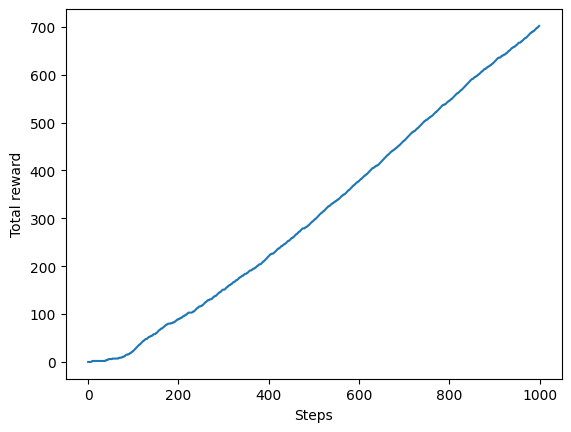

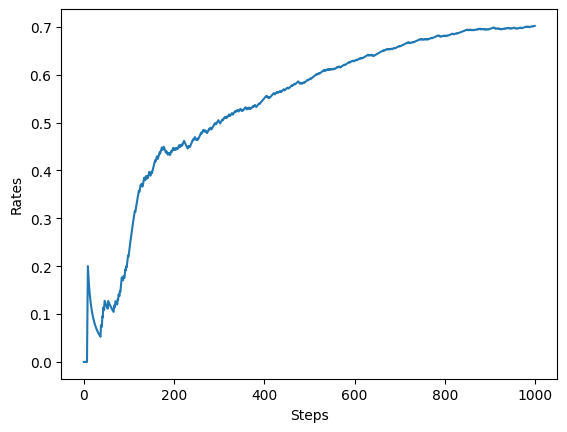

In [9]:
steps = 1000
epsilon = 0.1

bandit = Bandit()
agent = Agent(epsilon)
total_reward = 0
total_rewards = []  # 보상 합
rates = []          # 승률

for step in range(steps):
    action = agent.get_action()   # 행동 선택
    reward = bandit.play(action)  # 실제로 플레이하고 보상을 받음
    agent.update(action, reward)  # 행동과 보상을 통해 학습
    total_reward += reward

    total_rewards.append(total_reward)       # 현재까지의 보상 합 저장
    rates.append(total_reward / (step + 1))  # 현재까지의 승률 저장

print(total_reward)

# [그림 1-12] 단계별 보상 총합
plt.ylabel('Total reward')
plt.xlabel('Steps')
plt.plot(total_rewards)
plt.show()

# [그림 1-13] 단계별 승률
plt.ylabel('Rates')
plt.xlabel('Steps')
plt.plot(rates)
plt.show()

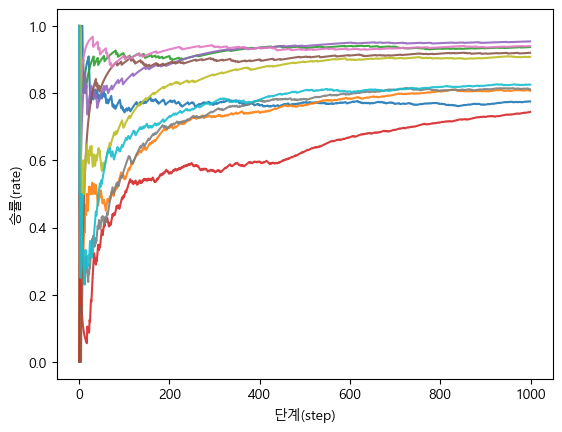

In [18]:
runs = 10      # 실험(에피소드) 반복 횟수
steps = 1000    # 한 번의 실험에서 슬롯머신을 플레이하는 횟수
epsilon = 0.1

all_rates = np.zeros((runs, steps))  # 실험별 승률 추이를 저장

for run in range(runs):  # n번의 실험 반복
    bandit = Bandit()
    agent = Agent(epsilon)
    total_reward = 0
    rates = []

    for step in range(steps):
        action = agent.get_action()
        reward = bandit.play(action)
        agent.update(action, reward)
        total_reward += reward
        rates.append(total_reward / (step + 1))

    all_rates[run] = rates  # 각 실험 결과를 저장

# n번의 실험 결과를 각각 하나의 그래프에 표시
plt.ylabel('승률(rate)')
plt.xlabel('단계(step)')
for run in range(runs):
    plt.plot(all_rates[run], alpha=0.9)
plt.show()

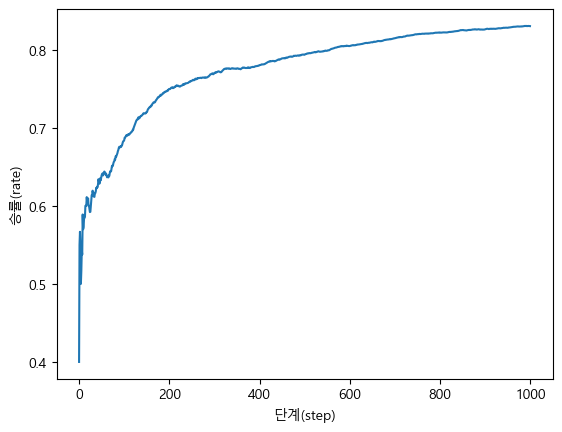

In [17]:
avg_rates = np.average(all_rates, axis=0)  # n번의 실험 결과를 평균내어 하나로 합침

# n번의 실험 결과를 하나의 그래프로 표시
plt.ylabel('승률(rate)')
plt.xlabel('단계(step)')
plt.plot(avg_rates)
plt.show()

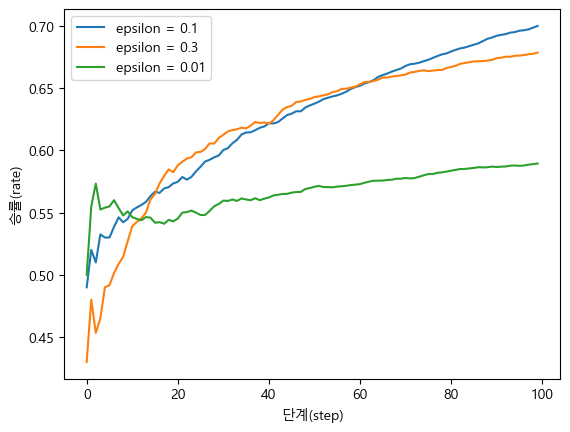

In [22]:
runs = 100      # 실험(에피소드) 반복 횟수
steps = 100    # 한 번의 실험에서 슬롯머신을 플레이하는 횟수
epsilons = [0.1, 0.3, 0.01]  # 비교할 epsilon 값 3개

plt.ylabel('승률(rate)')
plt.xlabel('단계(step)')

for epsilon in epsilons:
    all_rates = np.zeros((runs, steps))  # 실험별 승률 추이를 저장

    for run in range(runs):  # n번의 실험 반복
        bandit = Bandit()
        agent = Agent(epsilon)
        total_reward = 0
        rates = []

        for step in range(steps):
            action = agent.get_action()
            reward = bandit.play(action)
            agent.update(action, reward)
            total_reward += reward
            rates.append(total_reward / (step + 1))

        all_rates[run] = rates  # 각 실험 결과를 저장

    avg_rates = np.average(all_rates, axis=0)  # epsilon별로 n번의 실험 결과를 평균
    plt.plot(avg_rates, label=f'epsilon = {epsilon}')

plt.legend()
plt.show()